In [ ]:
!pip install tensorflow==2.17.1
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install wordcloud
!pip install nltk

In [ ]:
!pip install --upgrade ml_dtypes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.3 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.17.1 requires ml-dtypes<0.5.0,>=0.3.1, but you have ml-dtypes 0.5.3 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.17.1 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.17.1 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.17.1 which i

In [ ]:
# DL packages (TensorFlow 2.17+ uses tensorflow.keras only)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ML packages
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import pickle
import nltk
import re
from nltk.stem import PorterStemmer

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud



**Load Data**


In [ ]:
train_data= pd.read_csv('train.txt',header=None,sep=';',names=['Comment', 'Emotion'], encoding='utf-8')
#get all words length in comment
train_data['length'] = [len(x) for x in train_data['Comment']]
train_data

,Comment,Emotion,length
0,i didnt feel humiliated,sadness,23
1,i can go from feeling so hopeless to so damned...,sadness,108
2,im grabbing a minute to post i feel greedy wrong,anger,48
3,i am ever feeling nostalgic about the fireplac...,love,92
4,i am feeling grouchy,anger,20
...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,101
15996,i am now turning and i feel pathetic that i am...,sadness,102
15997,i feel strong and good overall,joy,30
15998,i feel like this was such a rude comment and i...,anger,59


In [ ]:
train_data.shape

(16000, 3)

In [ ]:
train_data.isnull().sum()

,0
Comment,0
Emotion,0
length,0


In [ ]:
train_data.duplicated().sum()

1

In [ ]:
train_data.drop_duplicates(inplace=True)

**EDA**

In [ ]:
train_data['Emotion'].value_counts()

,count
Emotion,
joy,5361
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


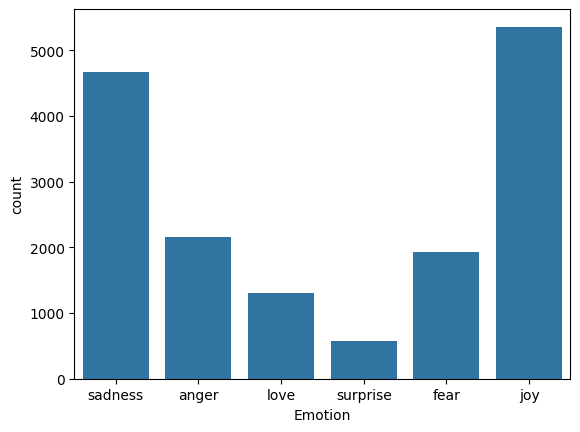

In [ ]:
sns.countplot(x=train_data['Emotion'])
plt.show()

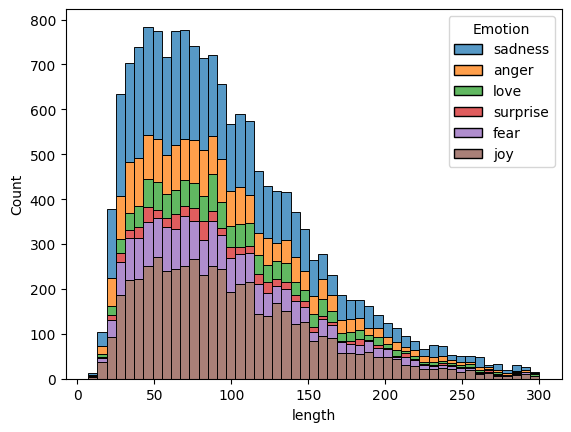

In [ ]:
#data distribution
df2= train_data.copy()
#convert the 'length' column to a numpy array
length_values = df2['length'].values
#use sns.histpot instead to sns.kdeplot for simplicity
sns.histplot(data=df2, x='length', hue='Emotion', multiple='stack')
plt.show()

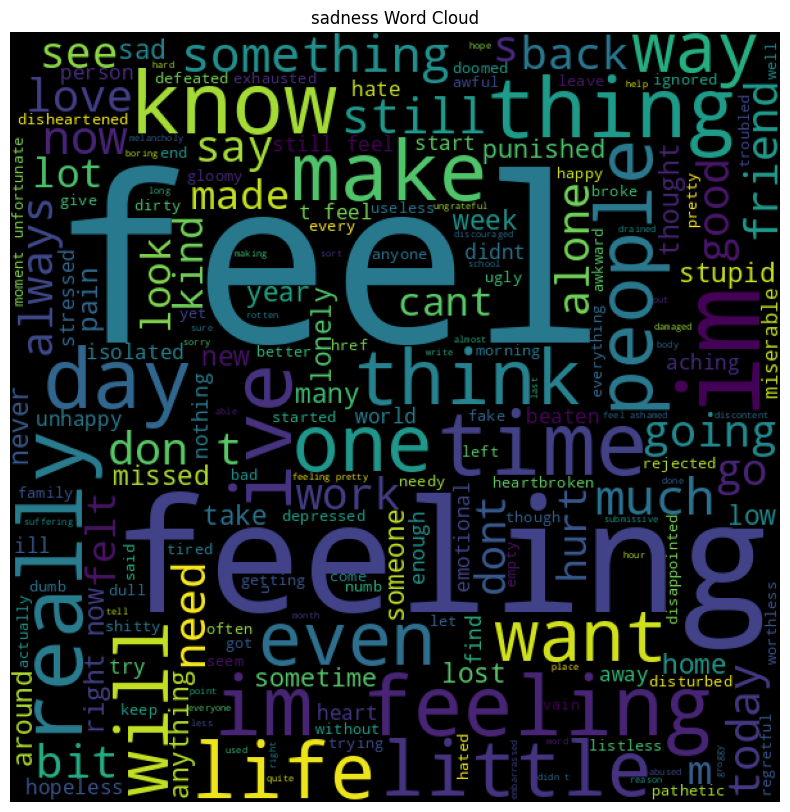

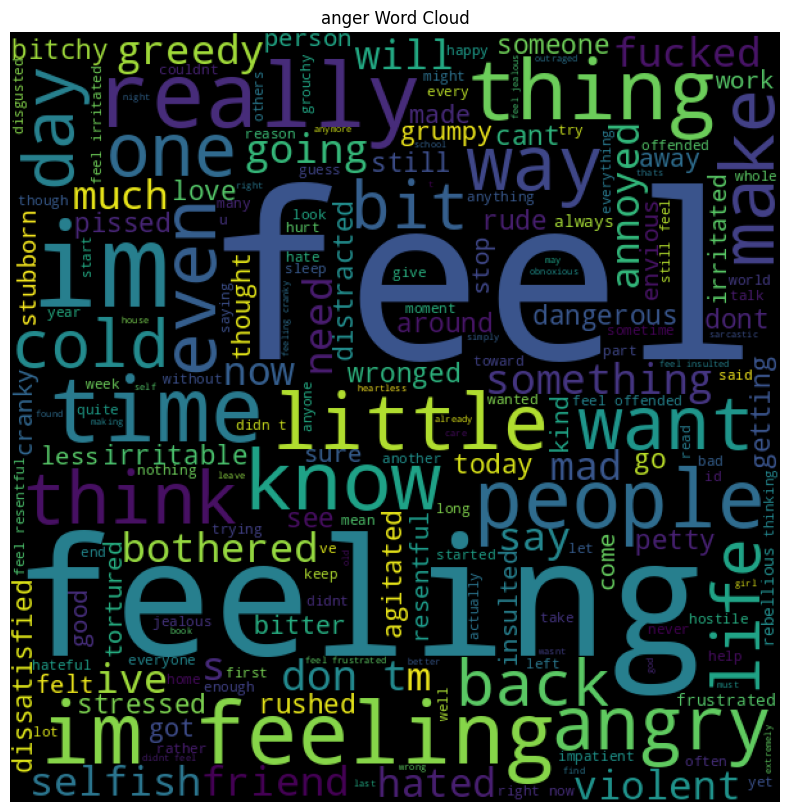

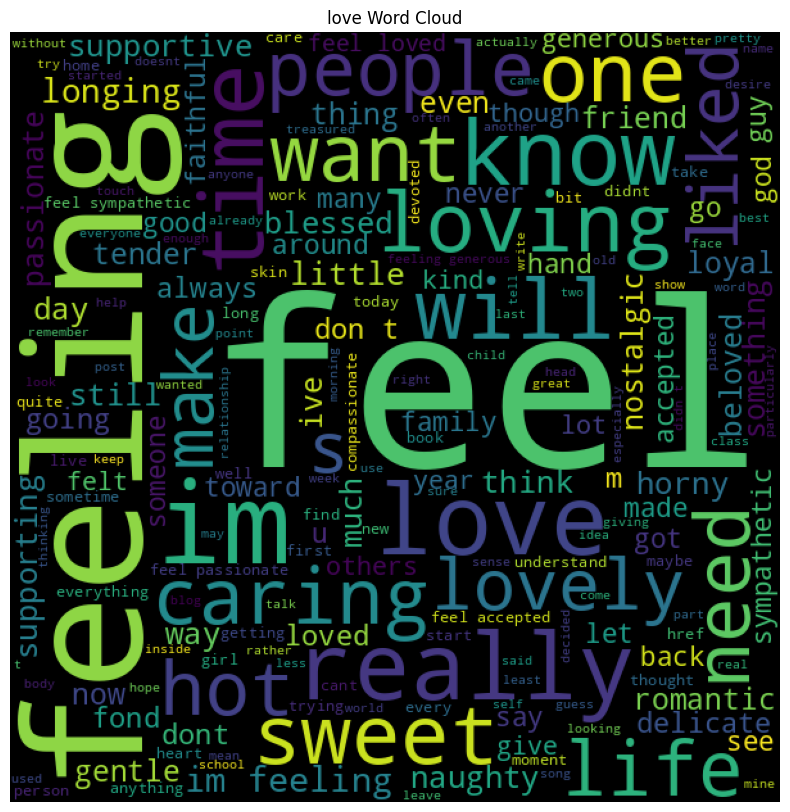

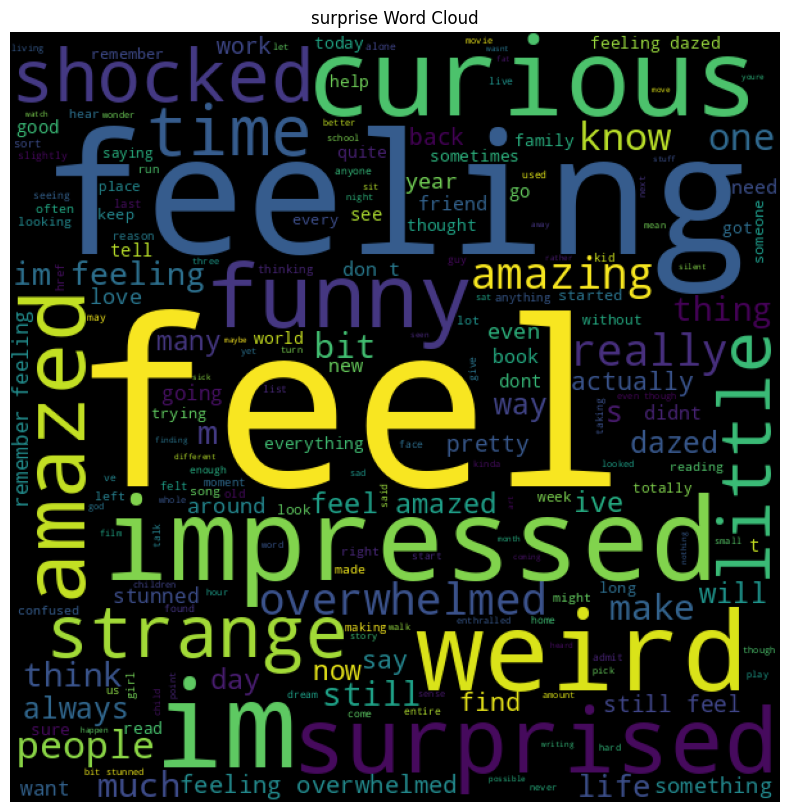

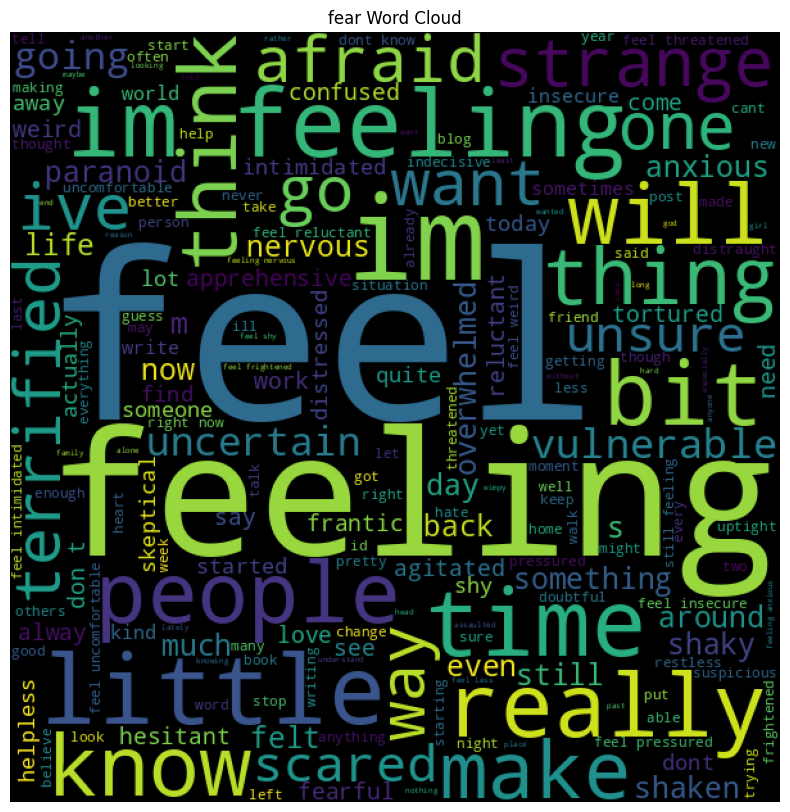

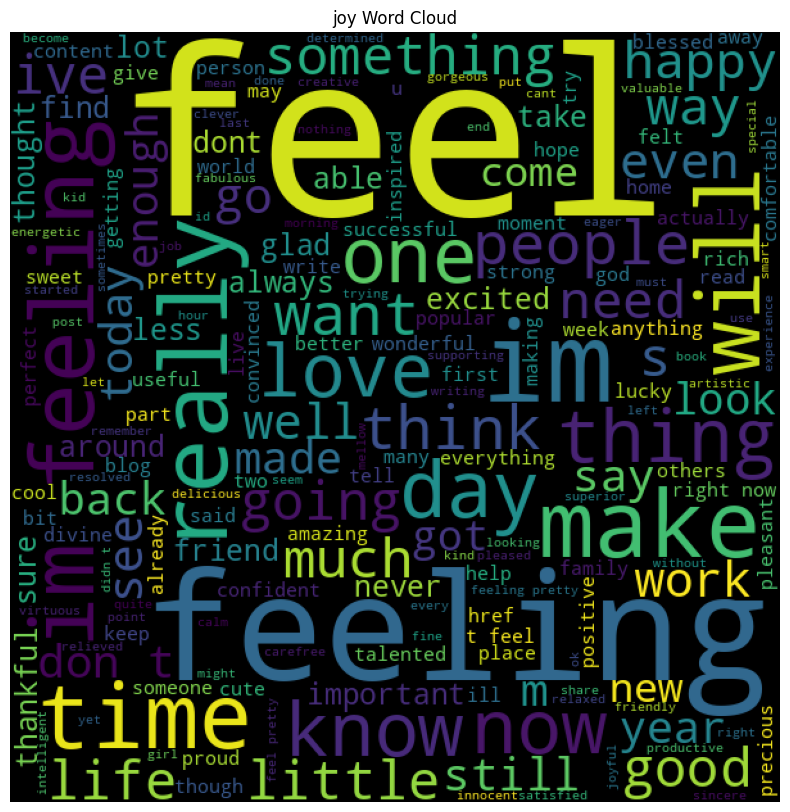

In [ ]:
#world cloud for each emotion
def words_cloud(wordcloud,emotion):
  plt.figure(figsize=(10,10))
  plt.title(emotion+' Word Cloud')
  plt.imshow(wordcloud)
  plt.axis('off')
emotions_list = train_data['Emotion'].unique()
for emotion in emotions_list:
  text= " ".join([sentence for sentence in train_data.loc[train_data['Emotion']==emotion, 'Comment']])
  wordcloud = WordCloud(width=600, height=600).generate(text)
  words_cloud(wordcloud, emotion)

**Data Processing**

**Encode Emotion**

In [ ]:
lb = LabelEncoder()
train_data['Emotion_Encoded']= lb.fit_transform(train_data['Emotion'])
train_data

,Comment,Emotion,length,Emotion_Encoded
0,i didnt feel humiliated,sadness,23,4
1,i can go from feeling so hopeless to so damned...,sadness,108,4
2,im grabbing a minute to post i feel greedy wrong,anger,48,0
3,i am ever feeling nostalgic about the fireplac...,love,92,3
4,i am feeling grouchy,anger,20,0
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,101,4
15996,i am now turning and i feel pathetic that i am...,sadness,102,4
15997,i feel strong and good overall,joy,30,2
15998,i feel like this was such a rude comment and i...,anger,59,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = train_data.copy()
df

,Comment,Emotion,length,Emotion_Encoded
0,i didnt feel humiliated,sadness,23,4
1,i can go from feeling so hopeless to so damned...,sadness,108,4
2,im grabbing a minute to post i feel greedy wrong,anger,48,0
3,i am ever feeling nostalgic about the fireplac...,love,92,3
4,i am feeling grouchy,anger,20,0
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,101,4
15996,i am now turning and i feel pathetic that i am...,sadness,102,4
15997,i feel strong and good overall,joy,30,2
15998,i feel like this was such a rude comment and i...,anger,59,0


In [ ]:
# Data cleaning and preprocessing
# Download NLTK stopwords
nltk.download('stopwords')
stopwords = set(nltk.corpus.stopwords.words('english'))
def clean_text(text):
    stemmer = PorterStemmer()
    text = re.sub("[^a-zA-Z]", " ", text)
    text = text.lower()
    text = text.split()
    text = [stemmer.stem(word) for word in text if word not in stopwords]
    return " ".join(text)

df['cleaned_comment'] = df['Comment'].apply(clean_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_comment'],df['Emotion'],test_size=0.2,random_state=42)

In [ ]:
# Vectorization using TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
# Multi-class classification using different algorithms
classifiers = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
}

for name, clf in classifiers.items():
    print(f"\n===== {name} =====")
    clf.fit(X_train_tfidf, y_train)
    y_pred_tfidf = clf.predict(X_test_tfidf)
    accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
    print(f"\nAccuracy using TF-IDF: {accuracy_tfidf}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_tfidf))


===== Multinomial Naive Bayes =====

Accuracy using TF-IDF: 0.6590625
Classification Report:
              precision    recall  f1-score   support

       anger       0.95      0.32      0.48       439
        fear       0.88      0.23      0.37       375
         joy       0.58      0.98      0.73      1027
        love       1.00      0.03      0.05       303
     sadness       0.72      0.91      0.80       950
    surprise       1.00      0.02      0.04       106

    accuracy                           0.66      3200
   macro avg       0.85      0.42      0.41      3200
weighted avg       0.76      0.66      0.59      3200


===== Logistic Regression =====

Accuracy using TF-IDF: 0.825
Classification Report:
              precision    recall  f1-score   support

       anger       0.88      0.78      0.83       439
        fear       0.85      0.72      0.78       375
         joy       0.76      0.94      0.84      1027
        love       0.84      0.47      0.60       303
     s

In [ ]:
# 1. Fit LabelEncoder correctly
lb = LabelEncoder()
y_train_enc = lb.fit_transform(y_train)
y_test_enc = lb.transform(y_test)   # never use fit_transform here

# 2. TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 3. Train Logistic Regression
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(max_iter=500)
lg.fit(X_train_tfidf, y_train_enc)

# 4. Prediction function
def predict_emotion(input_text):
    cleaned = clean_text(input_text)

    input_vec = tfidf_vectorizer.transform([cleaned])

    # Predict encoded label (integer)
    pred_id = lg.predict(input_vec)[0]

    # Convert back to emotion string
    emotion = lb.inverse_transform([pred_id])[0]

    return emotion, pred_id

# 5. Test the model
sentences = [
    "i didnt feel humiliated",
    "i feel strong and good overall",
    "im grabbing a minute to post i feel greedy wrong",
    "He was speechles when he found out he was accepted to this new job",
    "This is outrageous, how can you talk like that?",
    "I feel like im all alone in this world",
    "He is really sweet and caring",
    "You made me very crazy",
    "i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
    "i am feeling grouchy",
    "He hates you"
]

for s in sentences:
    print(s)
    emotion, code = predict_emotion(s)
    print("Prediction:", emotion)
    print("Label ID:", code)
    print("====================================================")


i didnt feel humiliated
Prediction: sadness
Label ID: 4
i feel strong and good overall
Prediction: joy
Label ID: 2
im grabbing a minute to post i feel greedy wrong
Prediction: anger
Label ID: 0
He was speechles when he found out he was accepted to this new job
Prediction: joy
Label ID: 2
This is outrageous, how can you talk like that?
Prediction: anger
Label ID: 0
I feel like im all alone in this world
Prediction: sadness
Label ID: 4
He is really sweet and caring
Prediction: love
Label ID: 3
You made me very crazy
Prediction: sadness
Label ID: 4
i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Prediction: love
Label ID: 3
i am feeling grouchy
Prediction: anger
Label ID: 0
He hates you
Prediction: anger
Label ID: 0


In [ ]:
# save files
import pickle
pickle.dump(lg,open("logistic_regresion.pkl",'wb'))
pickle.dump(lb,open("label_encoder.pkl",'wb'))
pickle.dump(tfidf_vectorizer,open("tfidf_vectorizer.pkl",'wb'))

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1



**Applying Deep learning Using LSTM**

**Text Cleaning, Ecoding, and Padding**

In [ ]:
stopwords = set(nltk.corpus.stopwords.words('english'))


In [ ]:
def clean_text(df, column,vocab_size,max_len):
  stemmer= PorterStemmer()
  corpus=[]
  for text in df[column]:
    text = re.sub("[^a-zA-Z]", " ", text)
    text = text.lower()
    text = text.split()
    text = [stemmer.stem(w) for w in text if w not in stopwords]
    text = ''.join(text)
    corpus.append(text)
    print(len(corpus))

  one_hot_word = [one_hot(input_text=word, n=vocab_size)for word in corpus]
  pad = pad_sequences(sequences=one_hot_word, maxlen=max_len, padding='pre')
  return pad
x_train = clean_text(train_data,'Comment',vocab_size=11000,max_len=300)
x_train.shape

Streaming output truncated to the last 5000 lines.
11000
11001
11002
11003
11004
11005
11006
11007
11008
11009
11010
11011
11012
11013
11014
11015
11016
11017
11018
11019
11020
11021
11022
11023
11024
11025
11026
11027
11028
11029
11030
11031
11032
11033
11034
11035
11036
11037
11038
11039
11040
11041
11042
11043
11044
11045
11046
11047
11048
11049
11050
11051
11052
11053
11054
11055
11056
11057
11058
11059
11060
11061
11062
11063
11064
11065
11066
11067
11068
11069
11070
11071
11072
11073
11074
11075
11076
11077
11078
11079
11080
11081
11082
11083
11084
11085
11086
11087
11088
11089
11090
11091
11092
11093
11094
11095
11096
11097
11098
11099
11100
11101
11102
11103
11104
11105
11106
11107
11108
11109
11110
11111
11112
11113
11114
11115
11116
11117
11118
11119
11120
11121
11122
11123
11124
11125
11126
11127
11128
11129
11130
11131
11132
11133
11134
11135
11136
11137
11138
11139
11140
11141
11142
11143
11144
11145
11146
11147
11148
11149
11150
11151
11152
11153
11154
11155
11156
11157
1

(15999, 300)

In [ ]:
lb = LabelEncoder()
train_data['Emotion']= lb.fit_transform(train_data['Emotion'])

In [ ]:
y_train = to_categorical(train_data['Emotion'])

**Model Building and Training**

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=11000, output_dim=150, input_length=300))
model.add(Dropout(0.2))
model.add(LSTM(128))
model.add(Dropout(0.2))
model.add(Dense(64, activation='sigmoid'))
model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
callback = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
model.fit(x_train, y_train, epochs=10, batch_size=64, verbose=1, callbacks=[callback])

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 202s 787ms/step - accuracy: 0.3153 - loss: 1.6188
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 196s 784ms/step - accuracy: 0.3235 - loss: 1.5888
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 187s 747ms/step - accuracy: 0.4306 - loss: 1.4710
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 185s 739ms/step - accuracy: 0.5978 - loss: 1.0410
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 237s 948ms/step - accuracy: 0.6267 - loss: 0.8899
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 221s 886ms/step - accuracy: 0.6287 - loss: 0.8137
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 188s 752ms/step - accuracy: 0.6399 - loss: 0.7327
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 186s 744ms/step - accuracy: 0.6430 - loss: 0.6848
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 206s 761ms/step - accuracy: 0.6327 - loss: 0.6713
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 197s 741ms/step - accuracy: 0.6328 - loss: 0.6528


**Predictive System**

In [ ]:
# Text cleaning function
def sentence_cleaning(sentence):
    stemmer = PorterStemmer()
    corpus = []
    text = re.sub("[^a-zA-Z]", " ", sentence)
    text = text.lower()
    text = text.split()
    text = [stemmer.stem(word) for word in text if word not in stopwords]
    text = " ".join(text)
    corpus.append(text)
    one_hot_word = [one_hot(input_text=word, n=11000) for word in corpus]
    pad = pad_sequences(sequences=one_hot_word, maxlen=300, padding='pre')
    return pad

# load model and predict
sentences = [
            "i feel strong and good overall",
            "im grabbing a minute to post i feel greedy wrong",
            "He was speechles when he found out he was accepted to this new job",
            "This is outrageous, how can you talk like that?",
            "I feel like im all alone in this world",
            "He is really sweet and caring",
            "You made me very crazy",
            "i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
            "i am feeling grouchy",
            "He hates you"
            ]
for sentence in sentences:
    print(sentence)
    sentence = sentence_cleaning(sentence)
    result = lb.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
    proba =  np.max(model.predict(sentence))
    print(f"{result} : {proba}\n\n")


i feel strong and good overall
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
0 : 0.9321824312210083


im grabbing a minute to post i feel greedy wrong
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
2 : 0.34221962094306946


He was speechles when he found out he was accepted to this new job
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
0 : 0.49376603960990906


This is outrageous, how can you talk like that?
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
3 : 0.5465347766876221


I feel like im all alone in this world
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
4 : 0.9710615277290344


He is really sweet and caring
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
5 : 0.7145124077796936


You made me very crazy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
0 : 0.9565715193

**Save the model and files**

In [ ]:
model.save('my_model.keras')